# Hybrid AI — Tối Ưu Lịch Trình Xe Buýt TP.HCM

## Spatio-Temporal GNN (GCN + GRU) × Genetic Algorithm × Tabu Search

**Bài toán:** Cho mạng xe buýt $G = (V, E)$ gồm $|V|$ trạm, $|E|$ đoạn, $R$ tuyến, và khung phục vụ chia thành $S$ slot thời gian. Tìm **ma trận lịch khởi hành** $X \in \{0,1\}^{R \times S}$ ($X_{r,k}=1$: tuyến $r$ xuất bến tại slot $k$) sao cho tối thiểu:

$$\min_X \; \alpha \cdot W(X) + \beta \cdot C(X) + \gamma \cdot P(X)$$

- $W(X)$: tổng thời gian chờ có trọng số (demand × wait × congestion\_weight)
- $C(X)$: chi phí vận hành (số xe cần × đơn giá/giờ)
- $P(X)$: phạt vượt quỹ đội xe

**Pipeline:**
1. **Dữ liệu** — 8 bảng CSV chuẩn hóa (topology + vận hành + chuỗi thời gian)
2. **EDA** — phân tích nhu cầu, tốc độ, mạng lưới
3. **GNN** (PyTorch) — GCN captures spatial dependency, GRU captures temporal patterns → dự báo nhu cầu
4. **Lan truyền ùn tắc** — khuếch tán stress trên đồ thị: $h \leftarrow \alpha (P \cdot h) + (1-\alpha) h_0$
5. **Tối ưu** — GA khám phá không gian nghiệm, Tabu tinh chỉnh cục bộ
6. **Đánh giá** — trước/sau, biểu đồ, bảng lịch

In [1]:
import os, math, warnings
from dataclasses import dataclass
from datetime import datetime, time, timedelta, date
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as Fn
from torch.utils.data import TensorDataset, DataLoader
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, to_dense_adj

from sko.GA import RCGA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} — device: {DEVICE}")

PyTorch 2.8.0+cpu — device: cpu


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CẤU HÌNH + HẰNG SỐ MIỀN
# ═══════════════════════════════════════════════════════════════════════════════
# Data must already exist in data/*.csv (read-only mode)
REGENERATE = False  # kept for backward compatibility; not used
DATA_DIR   = os.path.join(os.path.abspath("."), "data")
SEED       = 42

CFG = dict(
    n_days       = 7,
    n_buses      = 12,
    trips_per_bus= 6,
    freq_min     = 15,        # snapshot interval
    base_date    = "2025-09-01",
    window       = 4,         # GNN look-back
    epochs       = 45,
    batch        = 32,
    lr           = 8e-4,
    gcn_hidden   = 32,
    gru_hidden   = 64,
    ga_pop       = 50,
    ga_iter      = 120,
    tabu_iter    = 80,
    slot_minutes = 30,        # granularity for optimizer
)

SERVICE_START = time(5, 0)
SERVICE_END   = time(19, 0)
SERVICE_SPAN  = (SERVICE_END.hour*60 + SERVICE_END.minute
               - SERVICE_START.hour*60 - SERVICE_START.minute)  # 840 min

# Đặc thù TP.HCM
MORNING_RUSH = (6, 9);   EVENING_RUSH = (16, 19)
RAIN_PROB    = 0.35
RUSH_MULT    = 1.8;  RAIN_DEM_MULT = 1.3;  RAIN_SPD_MULT = 0.6
AVG_SPEED    = 18.0       # km/h
AVG_DWELL    = 1.0        # phút / trạm
TURNAROUND   = 5.0        # phút quay đầu
COST_PER_BUS_HOUR = 45.0  # đơn vị chi phí trừu tượng

DEMAND_RANGE = {
    "hub": (40, 80), "residential": (20, 50), "commercial": (25, 60),
    "school": (15, 45), "terminal": (30, 70),
}

OPT_WAIT_W   = 0.7        # trọng số chờ trong objective
OPT_COST_W   = 0.3        # trọng số chi phí
FLEET_PENALTY = 2000.0     # phạt vượt đội xe

@dataclass
class BusStop:
    id: int; name: str; category: str; lat: float; lon: float

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dl = np.radians(lat2-lat1); do = np.radians(lon2-lon1)
    a = np.sin(dl/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(do/2)**2
    return float(R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)))

print("Config OK  |  Slot:", CFG["slot_minutes"], "ph  |  Service:", SERVICE_SPAN, "min")

Config OK  |  Slot: 30 ph  |  Service: 840 min


## 1  Tải mạng lưới từ CSV

Topology hoàn toàn từ `data/stops.csv`, `route_master.csv`, `route_stops.csv` — không hard-code trong code.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MẠNG LƯỚI — đọc CSV → đồ thị NetworkX
# ═══════════════════════════════════════════════════════════════════════════════
def _norm_code(x):
    s = str(x).strip()
    return s.zfill(2) if s.isdigit() else s

def load_network(data_dir):
    df_s  = pd.read_csv(os.path.join(data_dir, "stops.csv"))
    df_rm = pd.read_csv(os.path.join(data_dir, "route_master.csv"), dtype={"route_code": str})
    df_rs = pd.read_csv(os.path.join(data_dir, "route_stops.csv"), dtype={"route_code": str})
    df_rm["route_code"] = df_rm["route_code"].map(_norm_code)
    df_rs["route_code"] = df_rs["route_code"].map(_norm_code)

    stops = [BusStop(int(r.stop_id), r.stop_name, r.stop_category, r.latitude, r.longitude)
             for _, r in df_s.sort_values("stop_id").iterrows()]
    stop_map = {s.id: s for s in stops}

    routes = {}
    for code in sorted(df_rm["route_code"].unique()):
        rm = df_rm[df_rm["route_code"]==code].iloc[0]
        path = df_rs[df_rs["route_code"]==code].sort_values("sequence")["stop_id"].astype(int).tolist()
        routes[code] = dict(name=str(rm["route_name"]),
                            color=str(rm.get("color", "#607D8B")),
                            stops=path)
    return stops, stop_map, routes, sorted(routes.keys())

def build_graph(stops, stop_map, routes):
    G = nx.Graph()
    for s in stops:
        G.add_node(s.id, name=s.name, category=s.category, pos=(s.lon, s.lat))
    for rdef in routes.values():
        ids = rdef["stops"]
        for a, b in zip(ids[:-1], ids[1:]):
            if not G.has_edge(a, b):
                d = haversine(stop_map[a].lat, stop_map[a].lon, stop_map[b].lat, stop_map[b].lon)
                G.add_edge(a, b, distance_km=round(d, 3))
    return G

def compute_demand(stops, routes, rng):
    demand = {}
    for s in stops:
        lo, hi = DEMAND_RANGE[s.category]
        base = float(rng.uniform(lo, hi))
        n_r = sum(1 for r in routes.values() if s.id in r["stops"])
        demand[s.id] = round(base * (1.0 + 0.25*(n_r-1)), 1)
    return demand

def compute_rtt(graph, routes):
    rtt = {}
    for code, rdef in routes.items():
        ids = rdef["stops"]
        d = sum(graph[a][b]["distance_km"] for a, b in zip(ids[:-1], ids[1:]))
        one_way = (d / AVG_SPEED)*60 + len(ids)*AVG_DWELL
        rtt[code] = round(2*one_way + TURNAROUND, 1)
    return rtt

def route_dist_km(graph, routes, code):
    ids = routes[code]["stops"]
    return round(sum(graph[a][b]["distance_km"] for a, b in zip(ids[:-1], ids[1:])), 2)

def routes_serving(routes, sid):
    return [c for c, r in routes.items() if sid in r["stops"]]

# ── Load ──
rng = np.random.default_rng(SEED)
stops, stop_map, routes, route_codes = load_network(DATA_DIR)
G = build_graph(stops, stop_map, routes)
demand = compute_demand(stops, routes, rng)
route_rtt = compute_rtt(G, routes)
stop_ids = sorted(s.id for s in stops)
n_nodes = len(stop_ids)
wait_weight = {s.id: 1.0 for s in stops}

# ── PyG topology (nodes sorted = stop_ids order) ──
# from_networkx orders nodes by sorted(G.nodes()), which matches stop_ids
_pyg = from_networkx(G)
edge_index  = _pyg.edge_index          # (2, E) — reused by GNN + propagation
edge_weight = torch.ones(edge_index.shape[1])  # binary adjacency weights

print(f"Mạng: {n_nodes} trạm  |  {len(routes)} tuyến  |  {G.number_of_edges()} cạnh")
for c in route_codes:
    r = routes[c]
    print(f"  [{c}] {r['name']} — {len(r['stops'])} trạm — "
          f"{route_dist_km(G, routes, c)} km — RTT {route_rtt[c]:.0f} ph")

Mạng: 13 trạm  |  4 tuyến  |  17 cạnh
  [01] Bến Thành – Gò Vấp — 5 trạm — 19.34 km — RTT 144 ph
  [19] Bến Thành – An Sương — 8 trạm — 18.26 km — RTT 143 ph
  [52] Bến Thành – Thủ Đức — 4 trạm — 13.2 km — RTT 101 ph
  [65] Chợ Lớn – Thủ Đức — 5 trạm — 24.57 km — RTT 179 ph


## 2  Sinh / Tải dữ liệu (8 bảng CSV)

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ĐỌC DỮ LIỆU — chỉ load 8 bảng CSV có sẵn (không sinh)
# ═══════════════════════════════════════════════════════════════════════════════
TABLE_FILES = [
    "route_master",
    "stops",
    "network_segments",
    "buses",
    "trips",
    "stop_times",
    "spatiotemporal_snapshots",
    "operation_logs",
]

def _missing_files(data_dir):
    missing = []
    for t in TABLE_FILES:
        p = os.path.join(data_dir, f"{t}.csv")
        if not os.path.isfile(p):
            missing.append(p)
    return missing

def _load_tables(data_dir):
    tables_local = {}
    for t in TABLE_FILES:
        p = os.path.join(data_dir, f"{t}.csv")
        if t == "spatiotemporal_snapshots":
            tables_local[t] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            tables_local[t] = pd.read_csv(p)
    print(f"[data] Loaded {len(TABLE_FILES)} tables from {data_dir}")
    return tables_local

missing = _missing_files(DATA_DIR)
if missing:
    raise FileNotFoundError(
        "Missing required CSV files in data/. Please prepare these files first:\n"
        + "\n".join(f"- {p}" for p in missing)
    )

tables = _load_tables(DATA_DIR)
for k, df in tables.items():
    print(f"  {k:35s}  {len(df):>6,} × {len(df.columns)} cols")

[data] Loaded 8 tables from d:\bus-schedule-optimization\data
  route_master                              4 × 6 cols
  stops                                    13 × 5 cols
  network_segments                         18 × 7 cols
  buses                                    12 × 4 cols
  trips                                   504 × 6 cols
  stop_times                            2,772 × 5 cols
  spatiotemporal_snapshots             14,784 × 8 cols
  operation_logs                        2,772 × 8 cols


## 3  Khám phá dữ liệu (EDA)

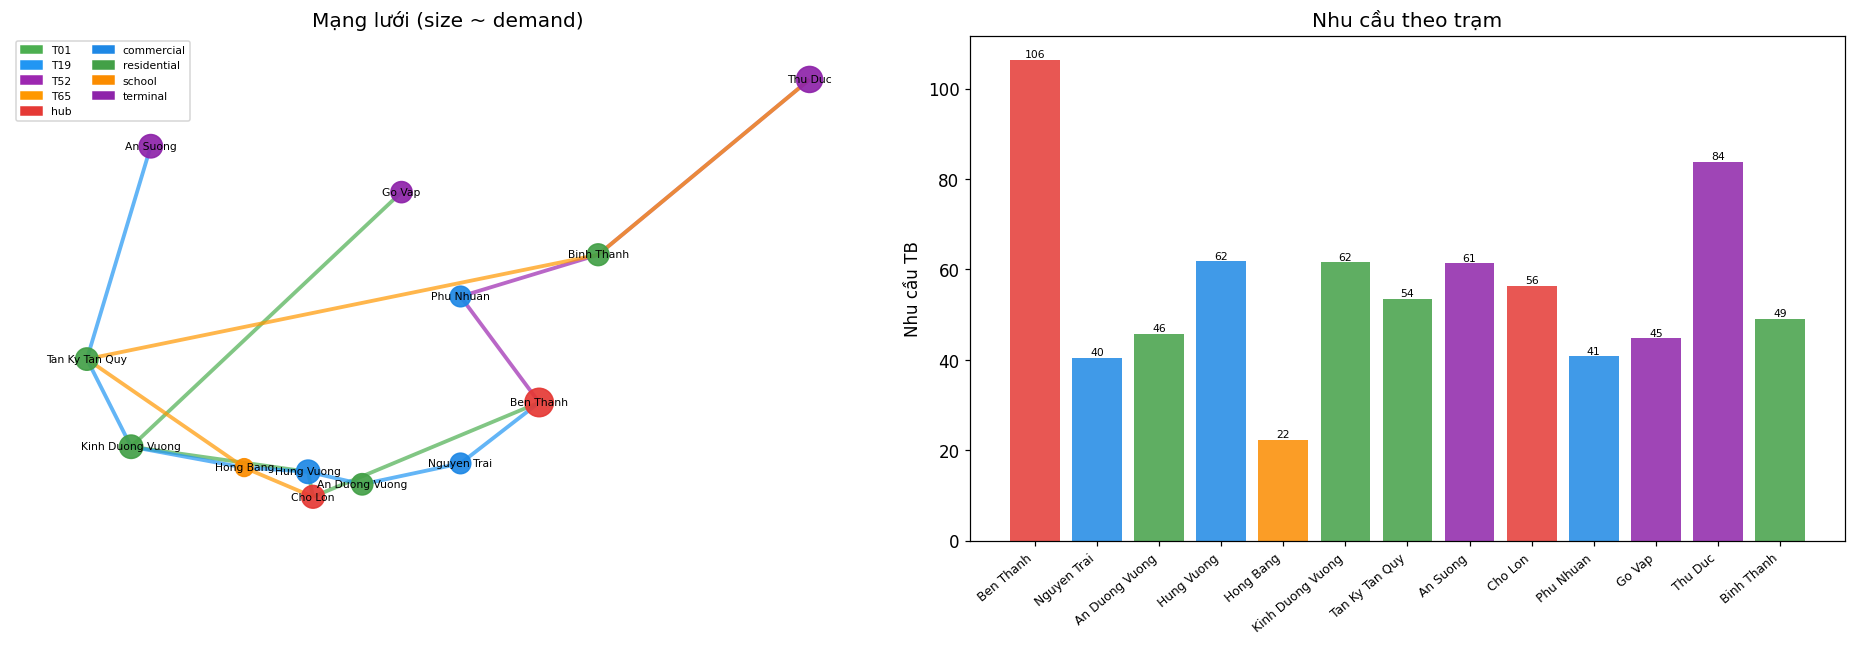

In [5]:
# ── 3.1  Đồ thị mạng + nhu cầu theo trạm ──────────────────────────────────────
RCOLORS = {c: routes[c]["color"] for c in route_codes}
CAT_CLR = {"hub":"#e53935","commercial":"#1e88e5","residential":"#43a047",
           "school":"#fb8c00","terminal":"#8e24aa"}
pos = {s.id: (s.lon, s.lat) for s in stops}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

# graph
nc = [CAT_CLR.get(s.category,"#888") for s in stops]
ns = [80 + demand[s.id]*2.5 for s in stops]
nx.draw_networkx_nodes(G, pos, node_color=nc, node_size=ns, ax=ax1, alpha=.92)
nx.draw_networkx_labels(G, pos, {s.id: s.name for s in stops}, font_size=7, ax=ax1)
for c in route_codes:
    ids = routes[c]["stops"]
    nx.draw_networkx_edges(G, pos, list(zip(ids[:-1], ids[1:])),
                           edge_color=RCOLORS[c], width=2.5, alpha=.7, ax=ax1,
                           connectionstyle=f"arc3,rad={0.07*route_codes.index(c)}")
p = [mpatches.Patch(color=v, label=f"T{k}") for k,v in RCOLORS.items()]
p += [mpatches.Patch(color=v, label=k) for k,v in CAT_CLR.items()]
ax1.legend(handles=p, fontsize=7, loc="upper left", ncol=2)
ax1.set_title("Mạng lưới (size ~ demand)"); ax1.axis("off")

# demand bar
sn = [stop_map[i].name for i in stop_ids]
dv = [demand[i] for i in stop_ids]
bars = ax2.bar(sn, dv, color=[CAT_CLR.get(stop_map[i].category,"#888") for i in stop_ids], alpha=.85)
ax2.set_xticklabels(sn, rotation=40, ha="right", fontsize=8)
ax2.set_ylabel("Nhu cầu TB"); ax2.set_title("Nhu cầu theo trạm")
for b, d in zip(bars, dv):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+.5, f"{d:.0f}", ha="center", fontsize=7)
plt.tight_layout(); plt.show()

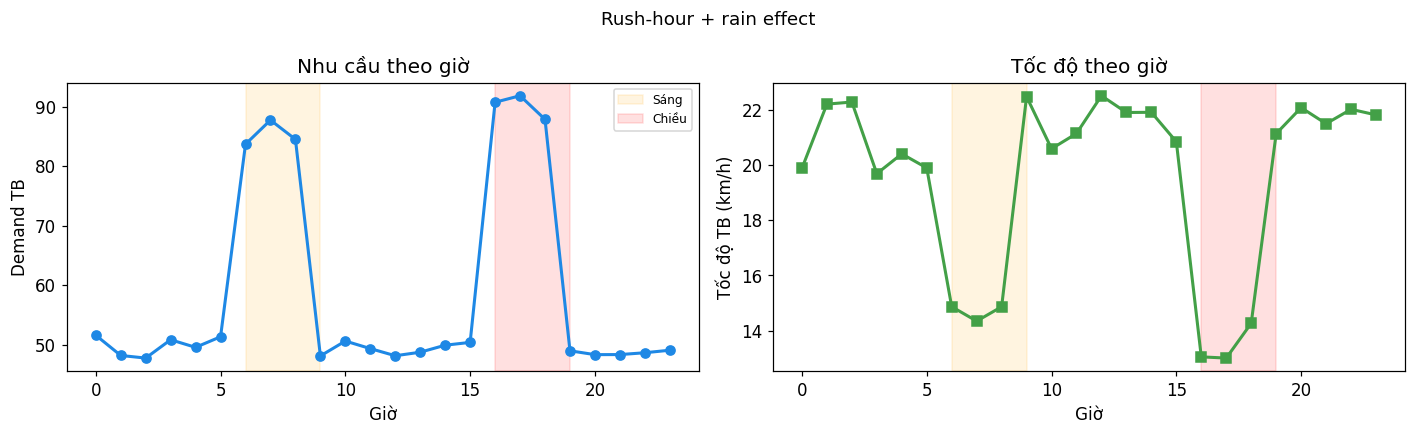

Rain %: 35.7%


In [6]:
# ── 3.2  Mẫu thời gian (rush / rain) ──────────────────────────────────────────
snap = tables["spatiotemporal_snapshots"].copy()
snap["hour"] = pd.to_datetime(snap["timestamp"]).dt.hour
by_h = snap.groupby("hour")[["demand_value","traffic_speed"]].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(by_h.index, by_h["demand_value"], "o-", color="#1e88e5", lw=2)
a1.axvspan(6,9, alpha=.12, color="orange", label="Sáng"); a1.axvspan(16,19, alpha=.12, color="red", label="Chiều")
a1.set_xlabel("Giờ"); a1.set_ylabel("Demand TB"); a1.set_title("Nhu cầu theo giờ"); a1.legend(fontsize=8)
a2.plot(by_h.index, by_h["traffic_speed"], "s-", color="#43a047", lw=2)
a2.axvspan(6,9, alpha=.12, color="orange"); a2.axvspan(16,19, alpha=.12, color="red")
a2.set_xlabel("Giờ"); a2.set_ylabel("Tốc độ TB (km/h)"); a2.set_title("Tốc độ theo giờ")
plt.suptitle("Rush-hour + rain effect", fontsize=12); plt.tight_layout(); plt.show()
print(f"Rain %: {snap['is_rain'].mean()*100:.1f}%")

=== route_master ===


,route_code,route_name,total_distance_km,service_start,service_end,color
0,1,Bến Thành – Gò Vấp,19.34,05:00,19:00,#4CAF50
1,19,Bến Thành – An Sương,18.26,05:00,19:00,#2196F3
2,52,Bến Thành – Thủ Đức,13.20,05:00,19:00,#9C27B0
3,65,Chợ Lớn – Thủ Đức,24.57,05:00,19:00,#FF9800


=== stops ===


,stop_id,stop_name,stop_category,latitude,longitude
0,0,Ben Thanh,hub,10.77,106.70
1,1,Nguyen Trai,commercial,10.76,106.68
2,2,An Duong Vuong,residential,10.75,106.66
3,3,Hung Vuong,commercial,10.76,106.65
4,4,Hong Bang,school,10.76,106.64
5,5,Kinh Duong Vuong,residential,10.76,106.61
6,6,Tan Ky Tan Quy,residential,10.78,106.61
7,7,An Suong,terminal,10.83,106.62
8,8,Cho Lon,hub,10.75,106.65
9,9,Phu Nhuan,commercial,10.80,106.68


=== buses ===


...

,trip_id,route_code,bus_id,direction,start_time,end_time
0,TRIP-2025-09-01-BUS-001-01,1,BUS-001,outbound,2025-09-01T05:32:41,2025-09-01T07:56:41
1,TRIP-2025-09-01-BUS-001-02,1,BUS-001,outbound,2025-09-01T07:28:10,2025-09-01T09:52:10
2,TRIP-2025-09-01-BUS-001-03,1,BUS-001,outbound,2025-09-01T09:59:36,2025-09-01T12:23:36
3,TRIP-2025-09-01-BUS-001-04,1,BUS-001,outbound,2025-09-01T12:01:50,2025-09-01T14:25:50
4,TRIP-2025-09-01-BUS-001-05,1,BUS-001,outbound,2025-09-01T14:26:28,2025-09-01T16:50:28



=== stop_times (5 dòng đầu) ===


,trip_id,stop_id,arrival_time,departure_time,stop_sequence
0,TRIP-2025-09-01-BUS-001-01,0,2025-09-01T05:32:41,2025-09-01T05:33:31,1
1,TRIP-2025-09-01-BUS-001-01,8,2025-09-01T05:52:15,2025-09-01T05:52:47,2
2,TRIP-2025-09-01-BUS-001-01,3,2025-09-01T05:55:03,2025-09-01T05:55:50,3
3,TRIP-2025-09-01-BUS-001-01,5,2025-09-01T06:09:08,2025-09-01T06:09:56,4
4,TRIP-2025-09-01-BUS-001-01,10,2025-09-01T06:40:08,2025-09-01T06:40:44,5



=== operation_logs (5 dòng đầu) ===


,trip_id,bus_id,route_code,stop_id,actual_arrival,actual_departure,boarding_count,dwell_time_sec
0,TRIP-2025-09-01-BUS-001-01,BUS-001,1,0,2025-09-01T05:31:27,2025-09-01T05:32:14,15,47.50
1,TRIP-2025-09-01-BUS-001-01,BUS-001,1,8,2025-09-01T05:54:19,2025-09-01T05:54:40,8,21.10
2,TRIP-2025-09-01-BUS-001-01,BUS-001,1,3,2025-09-01T05:53:39,2025-09-01T05:54:12,0,32.50
3,TRIP-2025-09-01-BUS-001-01,BUS-001,1,5,2025-09-01T06:09:01,2025-09-01T06:09:52,0,50.50
4,TRIP-2025-09-01-BUS-001-01,BUS-001,1,10,2025-09-01T06:39:50,2025-09-01T06:40:23,0,33.50


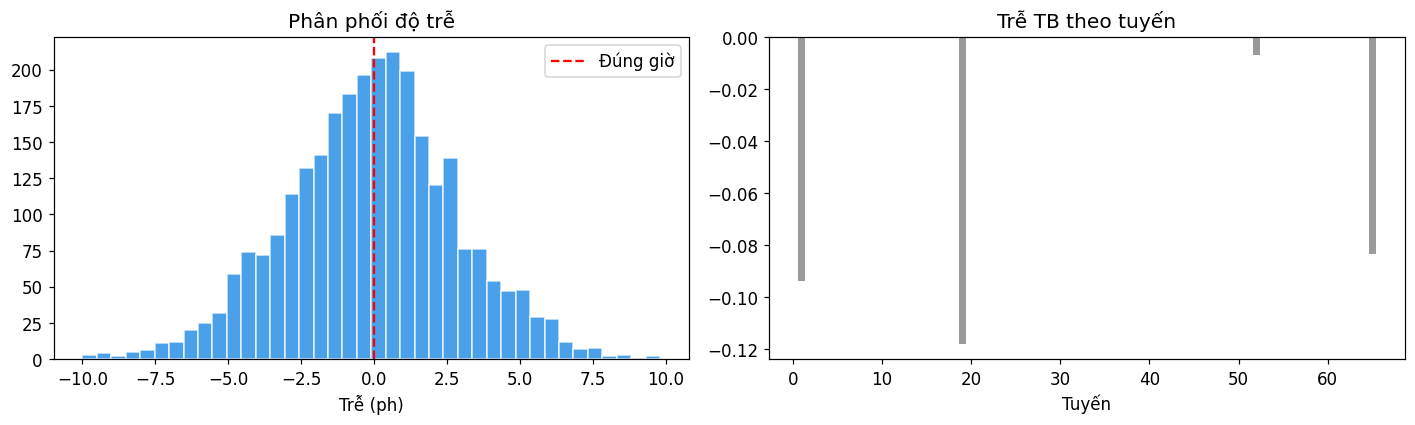

Trễ TB: -0.08 ph  |  Std: 2.91


In [7]:
# ── 3.3  Bảng dữ liệu + phân tích độ trễ ──────────────────────────────────────
for k in ["route_master","stops","buses"]:
    print(f"=== {k} ==="); display(tables[k])
print("=== route_stops ===")
display(pd.read_csv(os.path.join(DATA_DIR, "route_stops.csv")))
for k in ["trips","stop_times","operation_logs"]:
    print(f"\n=== {k} (5 dòng đầu) ==="); display(tables[k].head())

# Delay analysis
op = tables["operation_logs"].copy(); st = tables["stop_times"].copy()
op["actual_arrival"] = pd.to_datetime(op["actual_arrival"])
st["arrival_time"] = pd.to_datetime(st["arrival_time"])
mg = op.merge(st[["trip_id","stop_id","arrival_time"]], on=["trip_id","stop_id"], how="inner")
mg["delay_min"] = (mg["actual_arrival"] - mg["arrival_time"]).dt.total_seconds()/60

fig, (a1,a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.hist(mg["delay_min"].clip(-10,15), bins=40, color="#1e88e5", alpha=.8, edgecolor="white")
a1.axvline(0, color="red", ls="--", lw=1.5, label="Đúng giờ"); a1.legend()
a1.set_xlabel("Trễ (ph)"); a1.set_title("Phân phối độ trễ")
dr = mg.groupby("route_code")["delay_min"].mean()
a2.bar(dr.index, dr.values, color=[RCOLORS.get(c,"#888") for c in dr.index], alpha=.85)
a2.set_xlabel("Tuyến"); a2.set_title("Trễ TB theo tuyến")
plt.tight_layout(); plt.show()
print(f"Trễ TB: {mg['delay_min'].mean():.2f} ph  |  Std: {mg['delay_min'].std():.2f}")

## 4  Spatio-Temporal GNN — PyTorch Geometric (GCNConv + GRU)

**PyG GCNConv** (Kipf & Welling, 2017) với `edge_index` từ `from_networkx`:
$$H^{(l+1)} = \sigma\!\left(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} H^{(l)} W^{(l)}\right)$$

**Batch hiệu quả (topology cố định):** nhân đôi `edge_index` $B$ lần với offset $iN$ → một lần `GCNConv` cho cả batch, không tạo `Data`/`Batch` object. Chuỗi embedding qua **GRU** → dự báo demand tại $t+1$.

In [8]:
# ── 4.1  Chuẩn bị tensor cho GNN (PyG) ────────────────────────────────────────
def build_gnn_tensors(snapshots_df, sid_list, window):
    """Snapshots (long) → X (samples, window, N, 3), Y (samples, N)"""
    df = snapshots_df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    agg = (df.groupby(["timestamp","stop_id"], sort=True, as_index=False)
             .agg(demand_value=("demand_value","mean"),
                  traffic_speed=("traffic_speed","mean"),
                  is_rain=("is_rain","first")))
    timestamps = sorted(agg["timestamp"].unique())
    T, N = len(timestamps), len(sid_list)
    ts_i = {t: i for i, t in enumerate(timestamps)}
    si_i = {s: j for j, s in enumerate(sid_list)}
    dem = np.zeros((T, N), dtype=np.float32)
    spd = np.zeros((T, N), dtype=np.float32)
    rain = np.zeros(T, dtype=np.float32)
    for _, r in agg.iterrows():
        ti, ni = ts_i.get(r["timestamp"]), si_i.get(int(r["stop_id"]))
        if ti is not None and ni is not None:
            dem[ti, ni] = float(r["demand_value"])
            spd[ti, ni] = float(r["traffic_speed"])
            rain[ti] = float(r["is_rain"])
    Xs, Ys = [], []
    for t in range(T - window):
        feat = np.stack([dem[t:t+window], spd[t:t+window]], axis=-1)
        rfeat = np.tile(rain[t:t+window].reshape(-1,1,1), (1,N,1))
        Xs.append(np.concatenate([feat, rfeat], axis=-1))
        Ys.append(dem[t+window])
    return np.array(Xs, dtype=np.float32), np.array(Ys, dtype=np.float32)

# edge_index + edge_weight đã được tạo từ from_networkx ở cell 4; chỉ cần đưa lên DEVICE
ei = edge_index.to(DEVICE)
ew = edge_weight.to(DEVICE)

X_all, Y_all = build_gnn_tensors(tables["spatiotemporal_snapshots"], stop_ids, CFG["window"])
split = int(0.8 * len(X_all))
X_tr, X_val = X_all[:split], X_all[split:]
Y_tr, Y_val = Y_all[:split], Y_all[split:]

train_ds = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(Y_tr)),
                      batch_size=CFG["batch"], shuffle=True)
val_ds   = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(Y_val)),
                      batch_size=CFG["batch"])

print(f"X: {X_all.shape}  Y: {Y_all.shape}  |  Train: {len(X_tr)}  Val: {len(X_val)}")
print(f"Features: [demand, speed, rain]  |  Edges: {ei.shape[1]}")

X: (668, 4, 13, 3)  Y: (668, 13)  |  Train: 534  Val: 134
Features: [demand, speed, rain]  |  Edges: 34


In [9]:
# ── 4.2  Mô hình GCN + GRU (PyG — vectorized batched edge_index) ───────────────
class SpatioTemporalGNN(nn.Module):
    """
    Chiến lược batch hiệu quả với topology cố định:
      - Nhân đôi edge_index B lần (offset N mỗi graph) → 1 lần GCNConv cho cả batch
      - Không tạo Data/Batch object trong vòng lặp → ~B× nhanh hơn _batch_graph loop

    Per time-step:  x_t (B,N,F) → reshape (B*N,F) → GCNConv×2 → reshape (B,N*H)
    Over T steps:   [h₁…hT] → GRU → Linear → demand (B,N)
    """
    def __init__(self, n_feat, n_nodes, window, gcn_h=32, gru_h=64):
        super().__init__()
        self.gcn1    = GCNConv(n_feat, gcn_h, add_self_loops=True, normalize=True)
        self.gcn2    = GCNConv(gcn_h,  gcn_h, add_self_loops=True, normalize=True)
        self.gru     = nn.GRU(n_nodes * gcn_h, gru_h, batch_first=True)
        self.head    = nn.Linear(gru_h, n_nodes)
        self.n_nodes = n_nodes

    def _batch_ei(self, edge_index, B):
        """Repeat edge_index B times with per-graph node offset."""
        offsets = torch.arange(B, device=edge_index.device) * self.n_nodes  # (B,)
        return (edge_index.unsqueeze(0) + offsets.view(B, 1, 1)).view(2, -1)

    def forward(self, x_seq, edge_index, edge_weight=None):
        B, T, N, _ = x_seq.shape
        bei = self._batch_ei(edge_index, B)                     # (2, B*E)
        bew = edge_weight.repeat(B) if edge_weight is not None else None
        steps = []
        for t in range(T):
            xt = x_seq[:, t].reshape(B * N, -1)                # (B*N, F)
            h  = Fn.relu(self.gcn1(xt, bei, bew))              # (B*N, gcn_h)
            h  = Fn.relu(self.gcn2(h,  bei, bew))
            steps.append(h.view(B, -1))                         # (B, N*gcn_h)
        out, _ = self.gru(torch.stack(steps, dim=1))            # (B, T, gru_h)
        return self.head(out[:, -1])                            # (B, N)

model = SpatioTemporalGNN(
    n_feat   = X_all.shape[-1],
    n_nodes  = n_nodes,
    window   = CFG["window"],
    gcn_h    = CFG["gcn_hidden"],
    gru_h    = CFG["gru_hidden"],
).to(DEVICE)

print(f"Model: {sum(p.numel() for p in model.parameters()):,} params")
print(model)

Model: 94,573 params
SpatioTemporalGNN(
  (gcn1): GCNConv(3, 32)
  (gcn2): GCNConv(32, 32)
  (gru): GRU(416, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=13, bias=True)
)


  Epoch   1  train_loss=56.7625  val_loss=56.1763  val_mae=56.6763  lr=0.000800
  Epoch   5  train_loss=53.4619  val_loss=52.9174  val_mae=53.4174  lr=0.000800
  Epoch  10  train_loss=49.2472  val_loss=48.5937  val_mae=49.0937  lr=0.000800
  Epoch  15  train_loss=44.9908  val_loss=44.3837  val_mae=44.8837  lr=0.000800
  Epoch  20  train_loss=40.7850  val_loss=40.2343  val_mae=40.7342  lr=0.000800
  Epoch  25  train_loss=36.6361  val_loss=36.1287  val_mae=36.6278  lr=0.000800
  Epoch  30  train_loss=32.6666  val_loss=32.1171  val_mae=32.6129  lr=0.000800
  Epoch  35  train_loss=28.7514  val_loss=28.2483  val_mae=28.7422  lr=0.000800
  Epoch  40  train_loss=25.1449  val_loss=24.8511  val_mae=25.3460  lr=0.000800
  Epoch  45  train_loss=22.1884  val_loss=21.9311  val_mae=22.4245  lr=0.000800


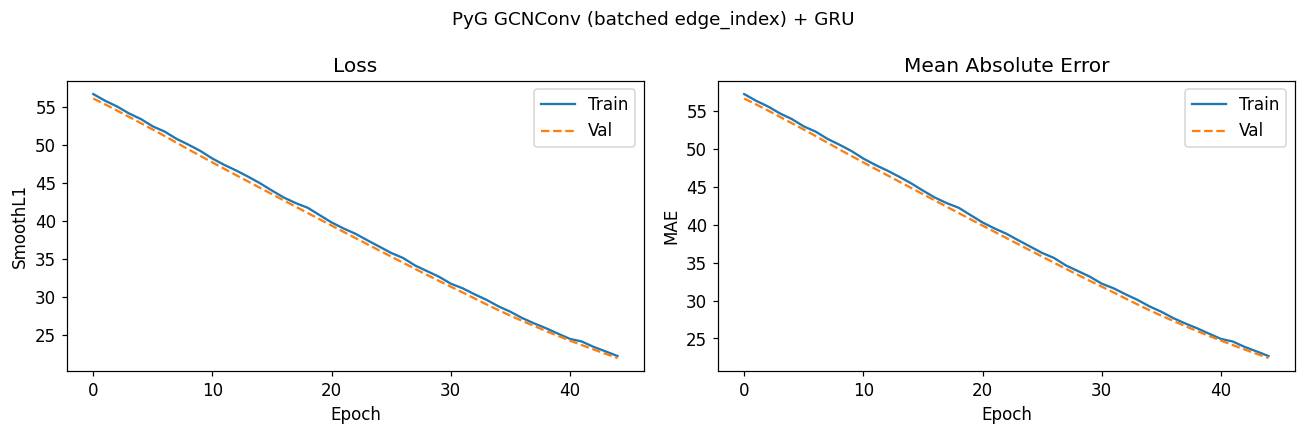

Best val MAE: 22.4245


In [10]:
# ── 4.3  Huấn luyện ───────────────────────────────────────────────────────────
torch.manual_seed(SEED)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=1e-5)
criterion = nn.SmoothL1Loss(beta=1.0)  # robust hơn MSE khi có outlier do rain/rush
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.6, patience=5, min_lr=1e-5
)

hist = {"train_loss":[], "val_loss":[], "train_mae":[], "val_mae":[]}
best_state = None
best_val = float("inf")
patience = 10
wait = 0

for epoch in range(1, CFG["epochs"]+1):
    # Train
    model.train(); losses, maes = [], []
    for xb, yb in train_ds:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb, ei, ew)
        loss = criterion(pred, yb)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())
        maes.append((pred - yb).abs().mean().item())
    hist["train_loss"].append(np.mean(losses))
    hist["train_mae"].append(np.mean(maes))

    # Val
    model.eval(); vl, vm = [], []
    with torch.no_grad():
        for xb, yb in val_ds:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb, ei, ew)
            vl.append(criterion(pred, yb).item())
            vm.append((pred - yb).abs().mean().item())
    val_loss = float(np.mean(vl)); val_mae = float(np.mean(vm))
    hist["val_loss"].append(val_loss)
    hist["val_mae"].append(val_mae)

    scheduler.step(val_loss)

    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:3d}  train_loss={hist['train_loss'][-1]:.4f}  "
              f"val_loss={val_loss:.4f}  val_mae={val_mae:.4f}  lr={lr_now:.6f}")

    if wait >= patience:
        print(f"  Early stopping at epoch {epoch} (best val_loss={best_val:.4f})")
        break

if best_state is not None:
    model.load_state_dict(best_state)

# ── Curves ──
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(hist["train_loss"], label="Train"); a1.plot(hist["val_loss"], "--", label="Val")
a1.set_xlabel("Epoch"); a1.set_ylabel("SmoothL1"); a1.set_title("Loss"); a1.legend()
a2.plot(hist["train_mae"], label="Train"); a2.plot(hist["val_mae"], "--", label="Val")
a2.set_xlabel("Epoch"); a2.set_ylabel("MAE"); a2.set_title("Mean Absolute Error"); a2.legend()
plt.suptitle("PyG GCNConv (batched edge_index) + GRU", fontsize=12)
plt.tight_layout(); plt.show()
print(f"Best val MAE: {min(hist['val_mae']):.4f}")

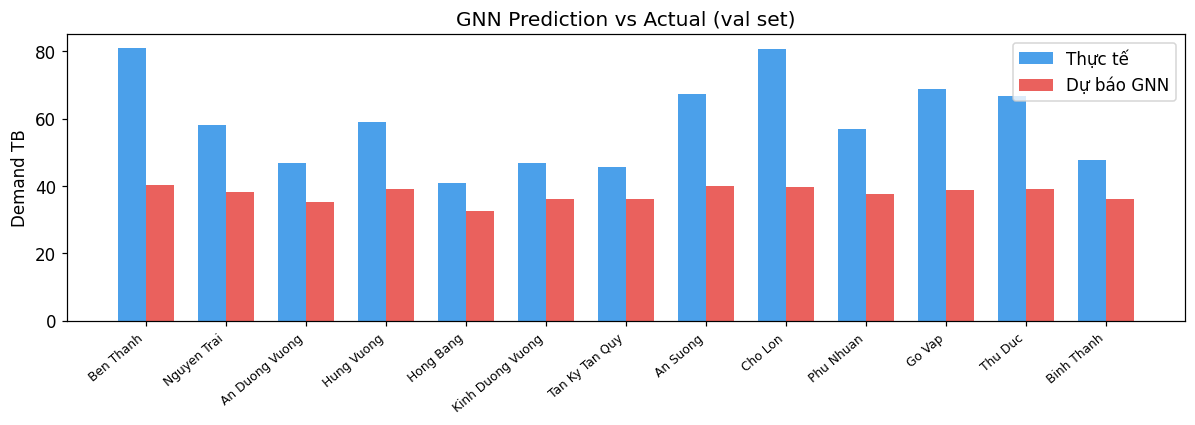

R² = -0.5857  |  MAE = 23.5190


In [11]:
# ── 4.4  Dự báo vs Thực tế ────────────────────────────────────────────────────
model.eval()
all_preds, all_actual = [], []
with torch.no_grad():
    for xb, yb in val_ds:
        p = model(xb.to(DEVICE), ei, ew)
        all_preds.append(p.cpu().numpy())
        all_actual.append(yb.numpy())
preds_np = np.concatenate(all_preds)
actual_np = np.concatenate(all_actual)

avg_pred   = preds_np.mean(axis=0)
avg_actual = actual_np.mean(axis=0)
speed_mean = np.mean(X_val[:, :, :, 1], axis=(0, 1))

fig, ax = plt.subplots(figsize=(11, 4))
x_idx = np.arange(n_nodes); w = 0.35
ax.bar(x_idx - w/2, avg_actual, w, label="Thực tế", alpha=.8, color="#1e88e5")
ax.bar(x_idx + w/2, avg_pred,   w, label="Dự báo GNN", alpha=.8, color="#e53935")
ax.set_xticks(x_idx)
ax.set_xticklabels([stop_map[i].name for i in stop_ids], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Demand TB"); ax.set_title("GNN Prediction vs Actual (val set)"); ax.legend()
plt.tight_layout(); plt.show()

# R² score
ss_res = np.sum((actual_np - preds_np)**2)
ss_tot = np.sum((actual_np - actual_np.mean())**2)
r2 = 1 - ss_res / ss_tot
print(f"R² = {r2:.4f}  |  MAE = {np.abs(actual_np - preds_np).mean():.4f}")

## 5  Lan truyền ùn tắc trên đồ thị

Stress cục bộ tại mỗi nút: $s_i = \hat{d}_i \cdot (0.35 + 0.65 \cdot \text{slowness}_i)$

Khuếch tán $K$ bước — adjacency từ `to_dense_adj(edge_index)` (cùng PyG topology với GCN):
$$h^{(k)} = \alpha \cdot P \cdot h^{(k-1)} + (1-\alpha) \cdot h^{(0)}, \quad P = D^{-1}(A+I)$$

Kết quả: `wait_weight[i]` (mean ≈ 1) → hàm mục tiêu optimizer ưu tiên trạm ùn tắc.

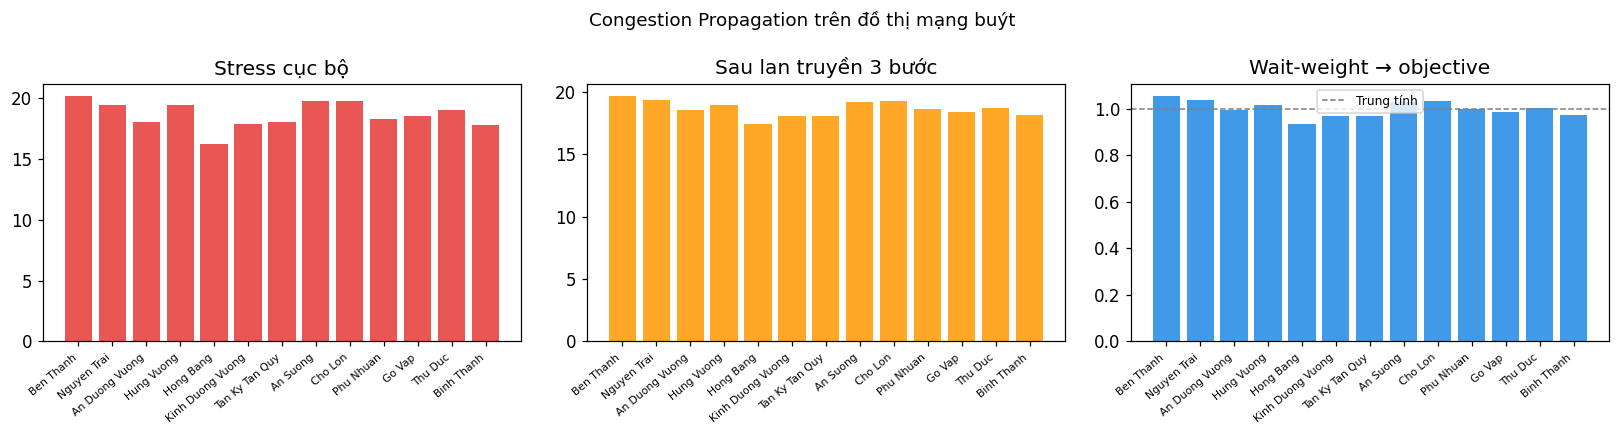

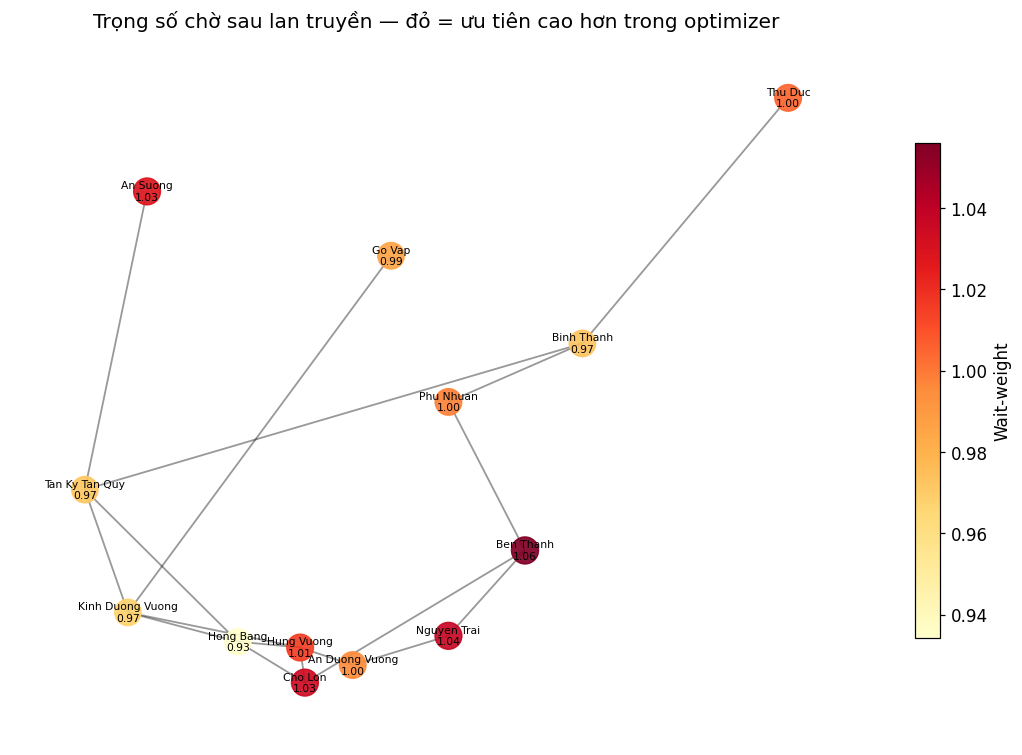

✓ demand + wait_weight cập nhật từ GNN (calibrated)


In [12]:
# ── 5.1  Propagation functions + visualize ─────────────────────────────────────
def row_norm_adj(A, add_self=True):
    a = A.copy().astype(np.float64)
    if add_self: a += np.eye(len(a))
    return a / np.maximum(a.sum(axis=1, keepdims=True), 1e-9)

def local_stress(dem, spd, ref=25.0):
    slow = np.clip((ref - spd) / ref, 0, 1)
    return np.maximum(dem, 0) * (0.35 + 0.65 * slow)

def propagate(A, loc, steps=3, mix=0.55):
    P = row_norm_adj(A)
    h = loc.copy(); h0 = h.copy()
    for _ in range(steps):
        h = mix * (P @ h) + (1 - mix) * h0
    return h

def stress_to_weights(s, lo=0.65, hi=1.85):
    w = s / np.maximum(np.mean(s), 1e-9)
    return np.clip(w, lo, hi)

loc_s  = local_stress(avg_pred, speed_mean)
# to_dense_adj từ PyG — dùng lại edge_index đã có, không cần nx.to_numpy_array
adj_for_prop = to_dense_adj(edge_index, max_num_nodes=n_nodes).squeeze(0).numpy().astype(np.float32)
prop_s = propagate(adj_for_prop, loc_s, steps=3, mix=0.55)
ww_arr = stress_to_weights(prop_s)
wait_weight = {int(sid): float(w) for sid, w in zip(stop_ids, ww_arr)}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
def _bar(ax, vals, title, color):
    ax.bar([stop_map[i].name for i in stop_ids], vals, color=color, alpha=.85)
    ax.set_xticklabels([stop_map[i].name for i in stop_ids], rotation=40, ha="right", fontsize=7)
    ax.set_title(title)
_bar(axes[0], loc_s,  "Stress cục bộ",         "#e53935")
_bar(axes[1], prop_s, "Sau lan truyền 3 bước",  "#ff9800")
_bar(axes[2], ww_arr, "Wait-weight → objective", "#1e88e5")
axes[2].axhline(1, color="gray", ls="--", lw=1, label="Trung tính"); axes[2].legend(fontsize=8)
plt.suptitle("Congestion Propagation trên đồ thị mạng buýt", fontsize=12)
plt.tight_layout(); plt.show()

# Heatmap trên graph
cmap = plt.cm.YlOrRd; norm_ = Normalize(ww_arr.min(), ww_arr.max())
fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color=[cmap(norm_(ww_arr[i])) for i in range(n_nodes)],
                       node_size=[120 + v*180 for v in ww_arr], ax=ax, alpha=.92)
nx.draw_networkx_labels(G, pos, {s.id: f"{s.name}\n{ww_arr[i]:.2f}"
    for i, s in enumerate(sorted(stops, key=lambda x: x.id))}, font_size=7, ax=ax)
nx.draw_networkx_edges(G, pos, width=1.2, alpha=.4, ax=ax)
sm = ScalarMappable(cmap=cmap, norm=norm_); sm.set_array([])
plt.colorbar(sm, ax=ax, label="Wait-weight", shrink=.7)
ax.set_title("Trọng số chờ sau lan truyền — đỏ = ưu tiên cao hơn trong optimizer")
ax.axis("off"); plt.tight_layout(); plt.show()

# Gán vào demand (calibrated) để optimizer ổn định hơn
# Blend prediction với observed mean để tránh optimizer bị lệch khi model dao động.
blend = 0.7
calibrated = blend * avg_pred + (1.0 - blend) * avg_actual
calibrated = np.clip(calibrated, a_min=1.0, a_max=None)
for s in stops:
    demand[s.id] = float(calibrated[stop_ids.index(s.id)])
print("✓ demand + wait_weight cập nhật từ GNN (calibrated)")

## 6  Tối ưu lịch khởi hành — GA + Tabu Search

Biến quyết định: $X \in \{0,1\}^{R \times S}$ (RCGA mã hóa liên tục $[0,1]$ → threshold 0.5 → nhị phân).

$$f(X) = \alpha \sum_{v} d_v \cdot w_v \cdot \text{wait}_v(X) + \beta \sum_r B_r \cdot C_h + \gamma \cdot \max(0, B_{total} - B_{fleet})$$

Trong đó $w_v$ = wait_weight từ GNN congestion, $B_r$ = xe cần cùng lúc trên tuyến $r$ (tính từ RTT overlap).

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
#  OPTIMIZER — hàm hỗ trợ + GA + Tabu
# ═══════════════════════════════════════════════════════════════════════════════
SM = CFG["slot_minutes"]
N_SLOTS = SERVICE_SPAN // SM

def cum_travel(route_code, sid):
    """Phút từ trạm đầu đến sid trên tuyến."""
    ids = routes[route_code]["stops"]
    if sid not in ids: return 0.0
    return sum(G[ids[i]][ids[i+1]]["distance_km"]/AVG_SPEED*60 for i in range(ids.index(sid)))

def mean_gap_wait(arrivals, horizon):
    A = sorted(t for t in arrivals if 0 <= t <= horizon)
    if len(A) == 0: return 60.0
    if len(A) == 1: return min(35.0, horizon/6)
    padded = [0.0] + A + [horizon]
    gaps = [padded[i+1]-padded[i] for i in range(len(padded)-1)]
    return sum(gaps)/len(gaps)/2

def wait_at_stops(sched, sm):
    horizon = float(SERVICE_SPAN); ns = N_SLOTS
    arr_at = {s.id: [] for s in stops}
    for ri, c in enumerate(route_codes):
        row = sched[ri]
        for k in range(min(ns, len(row))):
            if not row[k]: continue
            t0 = k * sm
            for sid in routes[c]["stops"]:
                a = t0 + cum_travel(c, sid)
                if 0 <= a <= horizon: arr_at[sid].append(a)
    return {sid: mean_gap_wait(arr_at[sid], horizon) for sid in arr_at}

def buses_on_route(code, row, sm):
    rtt = route_rtt[code]
    deps = [k*sm for k in range(len(row)) if row[k]]
    if not deps: return 0
    return max(sum(1 for t in deps if t<=tau<t+rtt)
               for tau in range(0, SERVICE_SPAN+1, 5))

def sched_to_bin(vec, n_r, n_s):
    return (vec.reshape(n_r, n_s) > 0.5).astype(bool)

def ensure_min(sched, mn=1):
    s = sched.copy()
    for r in range(s.shape[0]):
        if s[r].sum() < mn and s.shape[1] > 0: s[r, 0] = True
    return s

def compute_metrics(sched, sm=SM):
    codes = route_codes; wm = wait_at_stops(sched, sm)
    tot_dem = sum(demand[s.id] for s in stops)
    def ww(sid): return wait_weight.get(sid, 1.0)
    tot_wait = sum(demand[sid]*wm[sid]*ww(sid) for sid in wm)
    avg_w = tot_wait / max(tot_dem, 1e-6)
    prw = {}
    for c in codes:
        prw[c] = round(sum(demand[sid]*wm[sid]*ww(sid) for sid in routes[c]["stops"]), 2)
    buses, tot_b, tot_c, tpr = {}, 0, 0.0, {}
    hours = SERVICE_SPAN / 60
    for ri, c in enumerate(codes):
        row = sched[ri]; b = buses_on_route(c, row, sm)
        buses[c] = b; tot_b += b; tot_c += b * COST_PER_BUS_HOUR
        tpr[c] = int(row.sum())
    tph = {c: round(tpr[c]/hours, 2) if hours > 0 else 0 for c in codes}
    return dict(trips_per_route=tpr, trips_per_hour=tph, buses=buses,
                total_buses=tot_b, total_cost=round(tot_c,1),
                total_weighted_wait=round(tot_wait,1), avg_wait_min=round(avg_w,2),
                per_route_wait=prw,
                objective=round(OPT_WAIT_W*tot_wait + OPT_COST_W*tot_c, 2))

def baseline_sched(every_k=2):
    m = np.zeros((len(route_codes), N_SLOTS), dtype=bool)
    for r in range(m.shape[0]):
        for k in range(0, N_SLOTS, every_k): m[r, k] = True
    return m

class DepartureOptimizer:
    def __init__(self, fleet, ga_pop=50, ga_iter=100, tabu_iter=80, top_k=5):
        self.fleet = fleet; self.ga_pop = ga_pop; self.ga_iter = ga_iter
        self.tabu_iter = tabu_iter; self.top_k = top_k
        self.n_r = len(route_codes); self.n_s = N_SLOTS
        self.dim = self.n_r * self.n_s

    def _obj(self, vec):
        s = ensure_min(sched_to_bin(vec, self.n_r, self.n_s))
        m = compute_metrics(s)
        over = max(0, m["total_buses"] - self.fleet)
        return OPT_WAIT_W*m["total_weighted_wait"] + OPT_COST_W*m["total_cost"] + FLEET_PENALTY*over

    def _ga(self):
        ga = RCGA(func=self._obj, n_dim=self.dim, size_pop=self.ga_pop,
                  max_iter=self.ga_iter, lb=[0]*self.dim, ub=[1]*self.dim)
        bx, _ = ga.run()
        pop = ga.chrom2x(ga.Chrom)
        fits = np.array([self._obj(pop[i]) for i in range(len(pop))])
        idx = np.argsort(fits)[:self.top_k]
        return bx, [pop[i].copy() for i in idx]

    def _tabu(self, init):
        cur = np.clip(init.ravel(), 0, 1); best = cur.copy(); bc = self._obj(best)
        tabu_l = []
        for _ in range(self.tabu_iter):
            cands = []
            for i in range(self.dim):
                if i in tabu_l: continue
                n = cur.copy(); n[i] = 1.0 - n[i]
                cands.append((i, n, self._obj(n)))
            if not cands: tabu_l.clear(); continue
            cands.sort(key=lambda t: t[2])
            ci, cn, cc = cands[0]; cur = cn
            tabu_l.append(ci)
            if len(tabu_l) > self.dim//4: tabu_l.pop(0)
            if cc < bc: best, bc = cur.copy(), cc
        return best, bc

    def run(self):
        print("[opt] Phase 1: GA …")
        ga_best, elites = self._ga()
        print("[opt] Phase 2: Tabu …")
        bv = np.clip(ga_best.ravel(), 0, 1); bc = self._obj(bv)
        for e in elites:
            v, c = self._tabu(e.ravel())
            if c < bc: bv, bc = v, c
        s = ensure_min(sched_to_bin(bv, self.n_r, self.n_s))
        print(f"[opt] Best objective = {bc:.2f}")
        return s

print(f"Slots: {N_SLOTS}  |  Dim: {len(route_codes)} × {N_SLOTS} = {len(route_codes)*N_SLOTS}")

Slots: 28  |  Dim: 4 × 28 = 112


In [14]:
# ── 6.1  Chạy baseline + tối ưu ────────────────────────────────────────────────
sched_before = baseline_sched(every_k=2)
m_before = compute_metrics(sched_before)
print("=== BASELINE ===")
print(f"  Wait TB   : {m_before['avg_wait_min']:.2f} ph")
print(f"  Tổng xe   : {m_before['total_buses']}")
print(f"  Chi phí   : {m_before['total_cost']:.1f}")
print(f"  Objective : {m_before['objective']:.2f}")

opt = DepartureOptimizer(
    fleet=m_before["total_buses"],
    ga_pop=CFG["ga_pop"], ga_iter=CFG["ga_iter"], tabu_iter=CFG["tabu_iter"],
)
sched_after = opt.run()
m_after = compute_metrics(sched_after)
print("\n=== SAU TỐI ƯU ===")
print(f"  Wait TB   : {m_after['avg_wait_min']:.2f} ph")
print(f"  Tổng xe   : {m_after['total_buses']}")
print(f"  Chi phí   : {m_after['total_cost']:.1f}")
print(f"  Objective : {m_after['objective']:.2f}")

=== BASELINE ===
  Wait TB   : 19.75 ph
  Tổng xe   : 11
  Chi phí   : 495.0
  Objective : 8058.22
[opt] Phase 1: GA …
[opt] Phase 2: Tabu …
[opt] Best objective = 7616.45

=== SAU TỐI ƯU ===
  Wait TB   : 18.65 ph
  Tổng xe   : 11
  Chi phí   : 495.0
  Objective : 7616.48


## 7  Đánh giá kết quả

,Metric,Baseline,Optimized,Delta (%)
0,Chờ TB (ph),19.75,18.65,-5.60
1,Tổng xe,11.00,11.00,0.00
2,Chi phí,495.00,495.00,0.00
3,Objective,8058.22,7616.48,-5.50
4,Tổng chờ (trọng số),11299.60,10668.50,-5.60


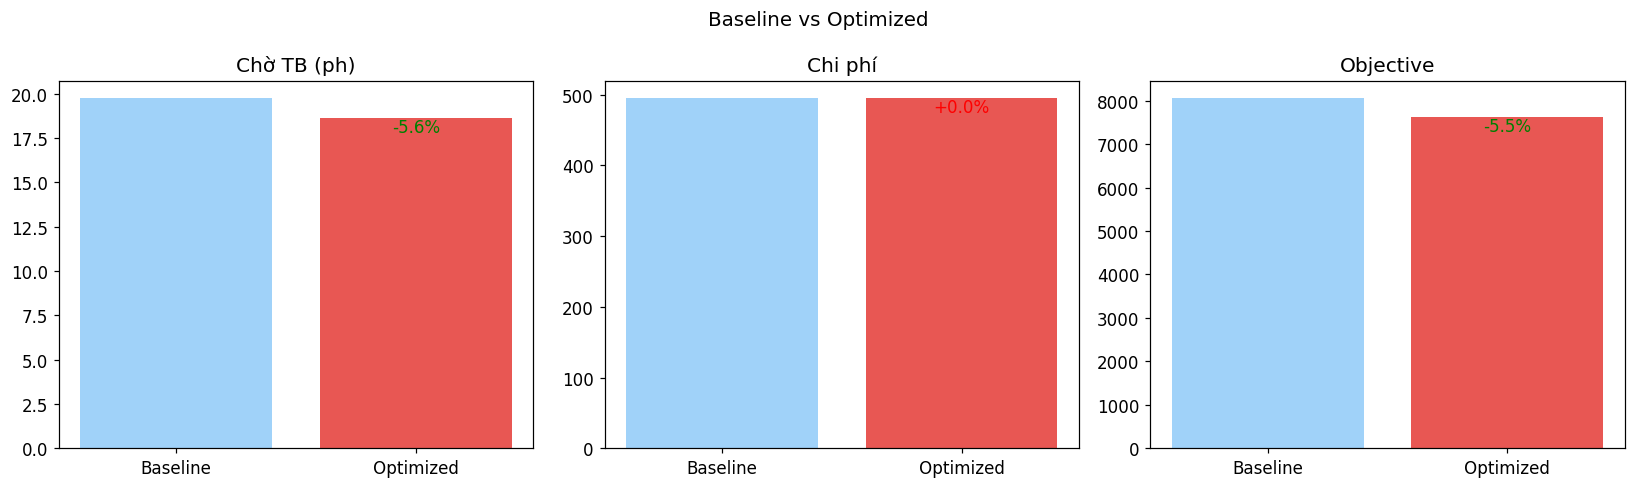

In [15]:
# ── 7.1  Bảng so sánh + bar chart ──────────────────────────────────────────────
comp = pd.DataFrame([
    {"Metric":"Chờ TB (ph)",     "Baseline":m_before["avg_wait_min"],       "Optimized":m_after["avg_wait_min"]},
    {"Metric":"Tổng xe",         "Baseline":m_before["total_buses"],        "Optimized":m_after["total_buses"]},
    {"Metric":"Chi phí",         "Baseline":m_before["total_cost"],         "Optimized":m_after["total_cost"]},
    {"Metric":"Objective",       "Baseline":m_before["objective"],          "Optimized":m_after["objective"]},
    {"Metric":"Tổng chờ (trọng số)", "Baseline":m_before["total_weighted_wait"],"Optimized":m_after["total_weighted_wait"]},
])
comp["Delta (%)"] = ((comp["Optimized"]-comp["Baseline"])/comp["Baseline"].replace(0,1)*100).round(1)
display(comp)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, (met, col) in enumerate(zip(["avg_wait_min","total_cost","objective"],
                                    ["Chờ TB (ph)","Chi phí","Objective"])):
    bv = m_before[met]; av = m_after[met]
    axes[i].bar(["Baseline","Optimized"], [bv, av], color=["#90caf9","#e53935"], alpha=.85)
    axes[i].set_title(col)
    pct = (av-bv)/max(abs(bv),1e-6)*100
    axes[i].annotate(f"{pct:+.1f}%", xy=(1, av), fontsize=11, ha="center",
                     va="bottom" if pct>0 else "top", color="green" if pct<0 else "red")
plt.suptitle("Baseline vs Optimized", fontsize=13); plt.tight_layout(); plt.show()

,Route,Name,Trips_B,Trips_A,TPH_B,TPH_A,Wait_B,Wait_A,Bus_B,Bus_A
0,01,Bến Thành – Gò Vấp,14,15,1.00,1.07,3946.66,3934.98,3,3
1,19,Bến Thành – An Sương,14,16,1.00,1.14,6623.04,6176.00,3,3
2,52,Bến Thành – Thủ Đức,14,20,1.00,1.43,3025.53,2585.43,2,3
3,65,Chợ Lớn – Thủ Đức,14,8,1.00,0.57,3075.28,3428.00,3,2


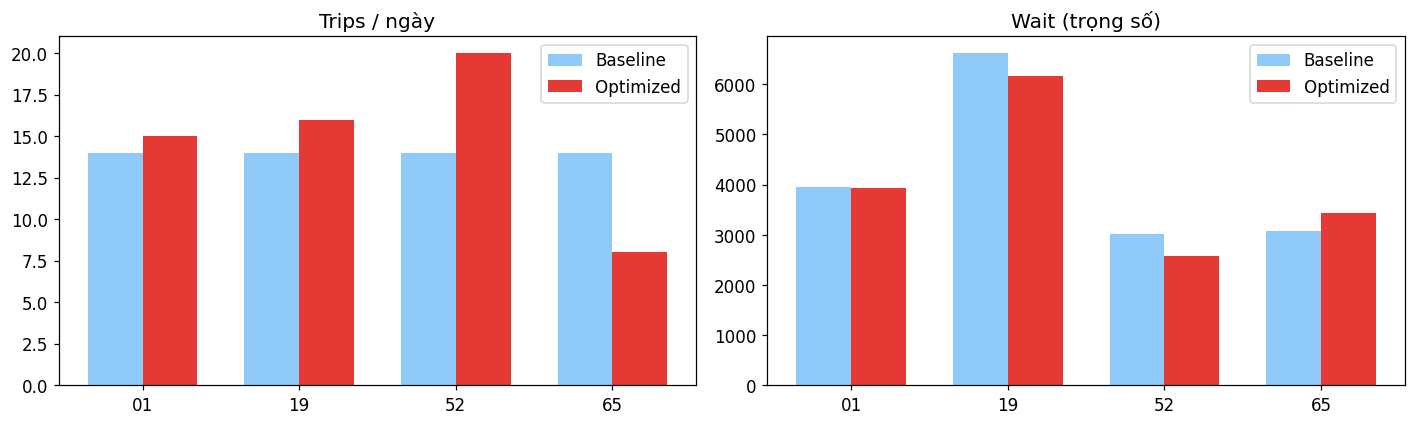

In [16]:
# ── 7.2  Phân tích theo tuyến ──────────────────────────────────────────────────
rows = []
for c in route_codes:
    rows.append(dict(Route=c, Name=routes[c]["name"],
                     Trips_B=m_before["trips_per_route"].get(c,0),
                     Trips_A=m_after["trips_per_route"].get(c,0),
                     TPH_B=m_before["trips_per_hour"].get(c,0),
                     TPH_A=m_after["trips_per_hour"].get(c,0),
                     Wait_B=m_before["per_route_wait"].get(c,0),
                     Wait_A=m_after["per_route_wait"].get(c,0),
                     Bus_B=m_before["buses"].get(c,0),
                     Bus_A=m_after["buses"].get(c,0)))
route_comp = pd.DataFrame(rows)
display(route_comp)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(route_codes)); w = 0.35
a1.bar(x-w/2, route_comp["Trips_B"], w, label="Baseline", color="#90caf9")
a1.bar(x+w/2, route_comp["Trips_A"], w, label="Optimized", color="#e53935")
a1.set_xticks(x); a1.set_xticklabels(route_codes); a1.legend(); a1.set_title("Trips / ngày")
a2.bar(x-w/2, route_comp["Wait_B"], w, label="Baseline", color="#90caf9")
a2.bar(x+w/2, route_comp["Wait_A"], w, label="Optimized", color="#e53935")
a2.set_xticks(x); a2.set_xticklabels(route_codes); a2.legend(); a2.set_title("Wait (trọng số)")
plt.tight_layout(); plt.show()

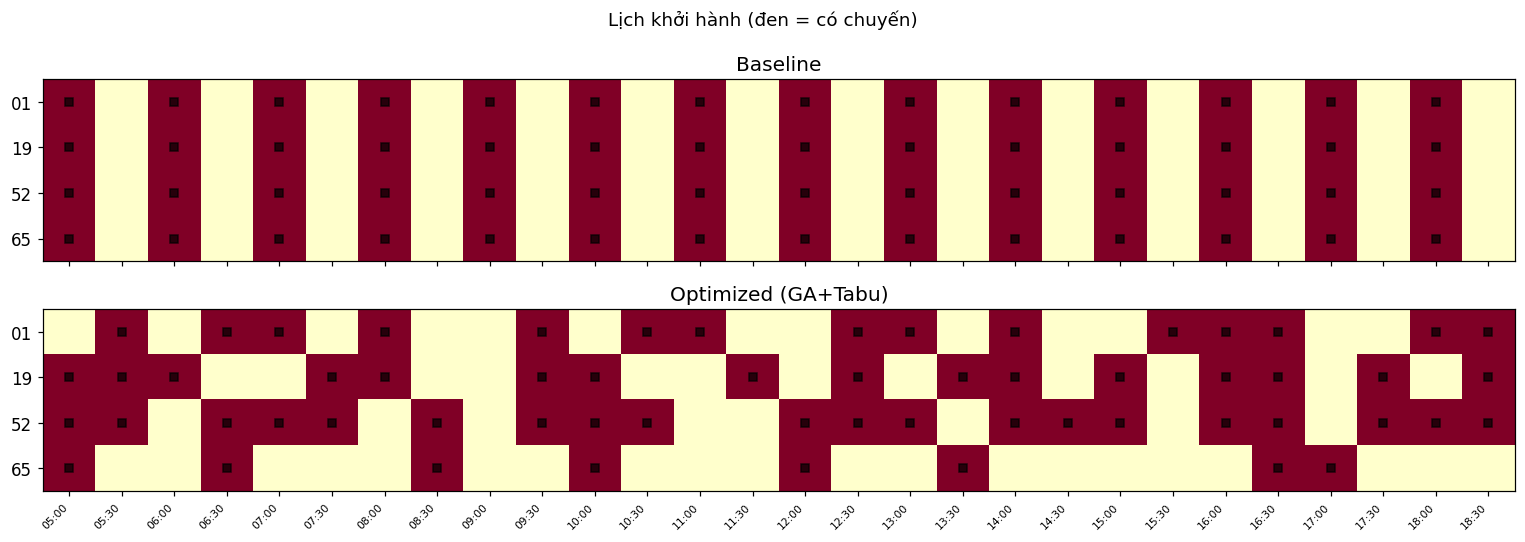

In [17]:
# ── 7.3  Schedule heatmap ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
time_labels = [f"{(SERVICE_START.hour*60 + k*SM)//60:02d}:{(SERVICE_START.hour*60 + k*SM)%60:02d}"
               for k in range(N_SLOTS)]
for ax, mat, title in [(ax1, sched_before, "Baseline"),
                        (ax2, sched_after, "Optimized (GA+Tabu)")]:
    ax.imshow(mat.astype(float), aspect="auto", cmap="YlOrRd", interpolation="nearest")
    ax.set_yticks(range(len(route_codes))); ax.set_yticklabels(route_codes)
    ax.set_title(title)
    for r in range(mat.shape[0]):
        for k in range(mat.shape[1]):
            if mat[r, k]: ax.plot(k, r, "ks", ms=5, alpha=.7)
ax2.set_xticks(range(N_SLOTS)); ax2.set_xticklabels(time_labels, rotation=45, ha="right", fontsize=7)
plt.suptitle("Lịch khởi hành (đen = có chuyến)", fontsize=12); plt.tight_layout(); plt.show()

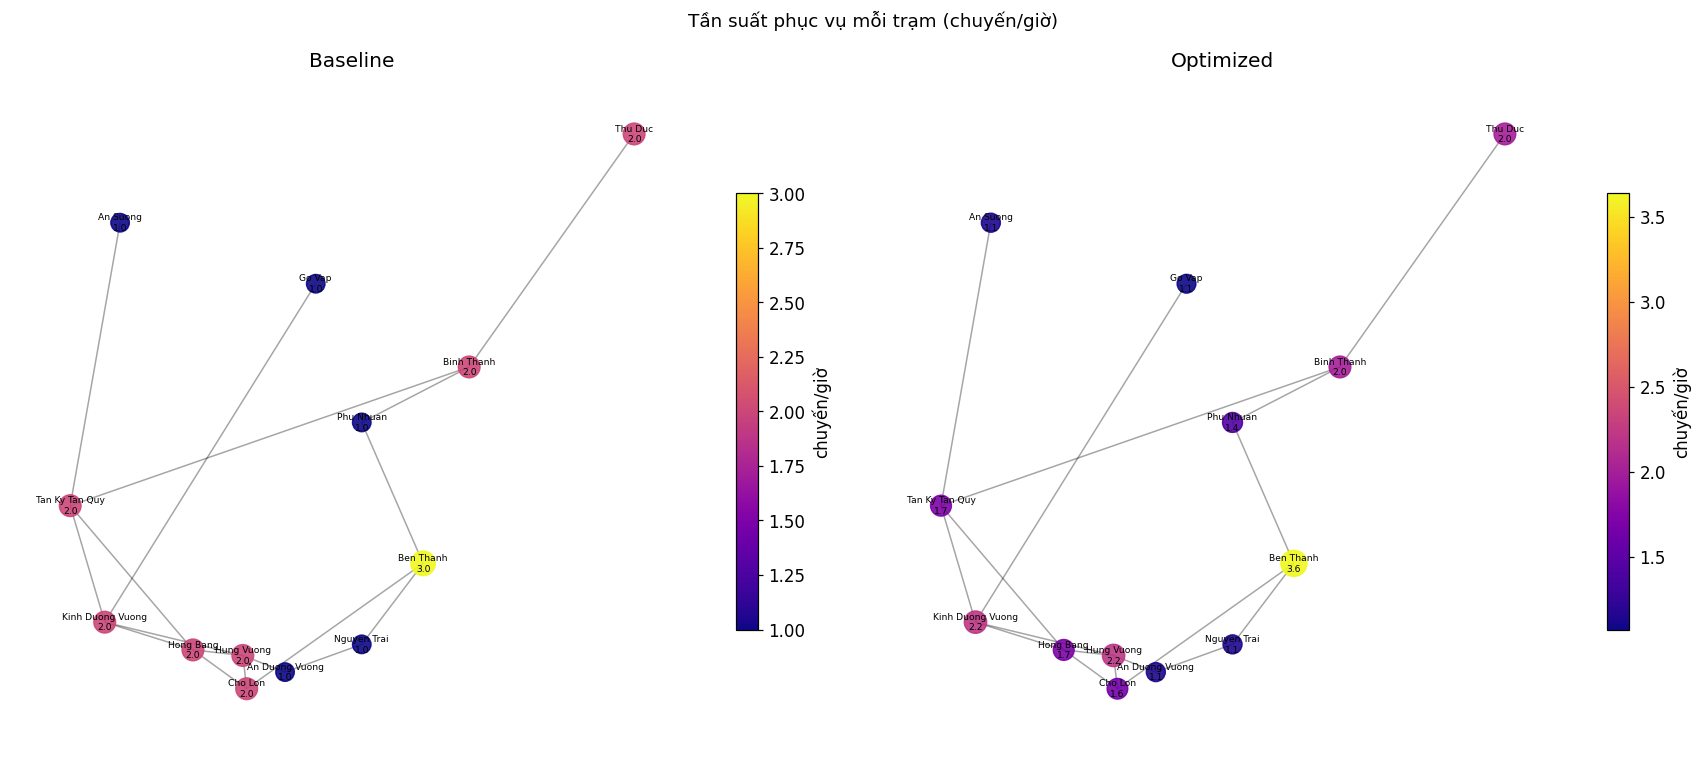

In [18]:
# ── 7.4  Network before/after ──────────────────────────────────────────────────
def freq_per_stop(sched, sm):
    hrs = SERVICE_SPAN / 60
    freq = {s.id: 0 for s in stops}
    for ri, c in enumerate(route_codes):
        n_t = int(sched[ri].sum())
        for sid in routes[c]["stops"]:
            freq[sid] += n_t
    return {sid: round(v/hrs, 2) for sid, v in freq.items()}

fbefore = freq_per_stop(sched_before, SM)
fafter  = freq_per_stop(sched_after, SM)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, freq, title in [(a1, fbefore, "Baseline"), (a2, fafter, "Optimized")]:
    vals = [freq.get(s.id, 0) for s in stops]
    mn, mx = min(vals), max(vals)
    norm_v = Normalize(mn, mx); cm = plt.cm.plasma
    nx.draw_networkx_nodes(G, pos, node_color=[cm(norm_v(v)) for v in vals],
                           node_size=[90 + v*55 for v in vals], ax=ax, alpha=.9)
    nx.draw_networkx_labels(G, pos, {s.id: f"{s.name}\n{vals[i]:.1f}" for i, s in enumerate(stops)},
                            font_size=6, ax=ax)
    nx.draw_networkx_edges(G, pos, width=1, alpha=.35, ax=ax)
    sm_ = ScalarMappable(cmap=cm, norm=norm_v); sm_.set_array([])
    plt.colorbar(sm_, ax=ax, shrink=.65, label="chuyến/giờ"); ax.set_title(title); ax.axis("off")
plt.suptitle("Tần suất phục vụ mỗi trạm (chuyến/giờ)", fontsize=12)
plt.tight_layout(); plt.show()

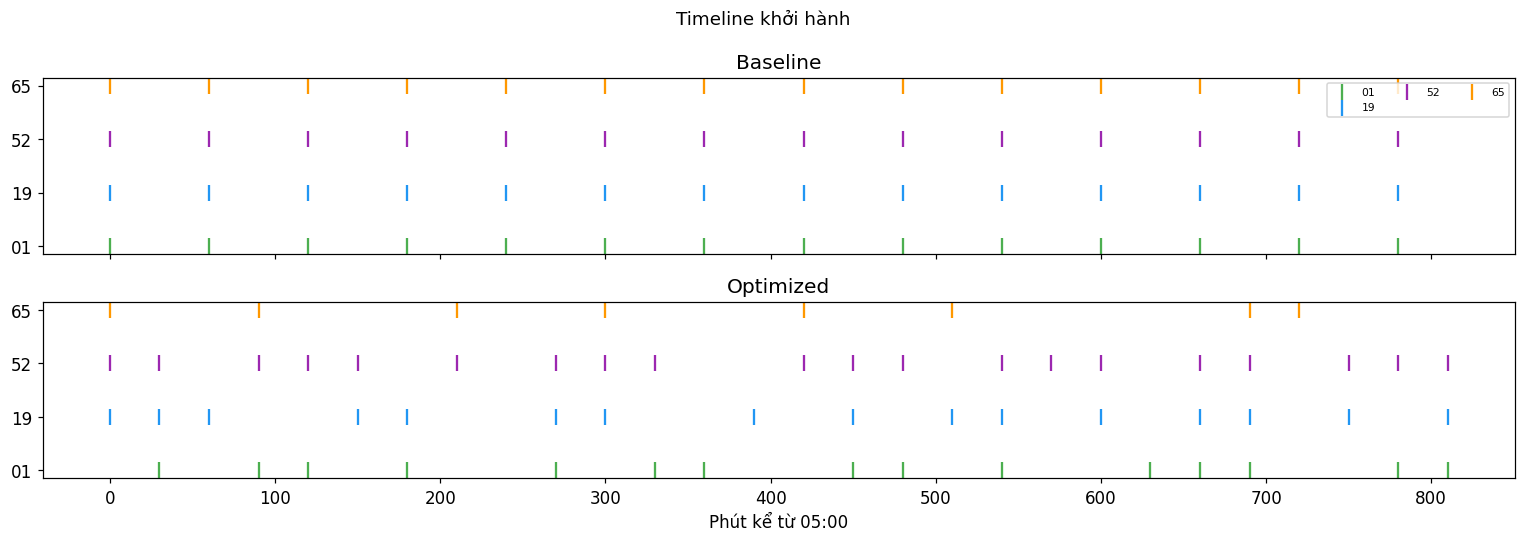

In [19]:
# ── 7.5  Departure scatter ─────────────────────────────────────────────────────
fig, (a1, a2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax, mat, title in [(a1, sched_before, "Baseline"), (a2, sched_after, "Optimized")]:
    for ri, c in enumerate(route_codes):
        slots_on = [k*SM for k in range(N_SLOTS) if mat[ri, k]]
        ax.scatter(slots_on, [ri]*len(slots_on), marker="|", s=120,
                   color=RCOLORS.get(c,"#888"), label=c if ri<len(route_codes) else "")
    ax.set_yticks(range(len(route_codes))); ax.set_yticklabels(route_codes)
    ax.set_title(title)
a2.set_xlabel("Phút kể từ 05:00")
a1.legend(fontsize=7, loc="upper right", ncol=3)
plt.suptitle("Timeline khởi hành", fontsize=12); plt.tight_layout(); plt.show()

In [20]:
# ── 7.6  Bảng lịch trình chi tiết ──────────────────────────────────────────────
rows = []
for ri, c in enumerate(route_codes):
    for k in range(N_SLOTS):
        if sched_after[ri, k]:
            t0 = SERVICE_START.hour*60 + SERVICE_START.minute + k*SM
            hh, mm = divmod(t0, 60)
            rows.append(dict(Route=c, Slot=k, Departure=f"{hh:02d}:{mm:02d}",
                             RTT_min=route_rtt[c],
                             Return=f"{(hh*60+mm+int(route_rtt[c]))//60:02d}:{(mm+int(route_rtt[c]))%60:02d}"))
sched_df = pd.DataFrame(rows)
print(f"Tổng {len(sched_df)} chuyến/ngày:")
display(sched_df)

Tổng 59 chuyến/ngày:


,Route,Slot,Departure,RTT_min,Return
0,01,1,05:30,144.00,07:54
1,01,3,06:30,144.00,08:54
2,01,4,07:00,144.00,09:24
3,01,6,08:00,144.00,10:24
4,01,9,09:30,144.00,11:54
5,01,11,10:30,144.00,12:54
6,01,12,11:00,144.00,13:24
7,01,15,12:30,144.00,14:54
8,01,16,13:00,144.00,15:24
9,01,18,14:00,144.00,16:24


In [21]:
# ── 7.7  Tổng kết ─────────────────────────────────────────────────────────────
pct_w = (m_after["avg_wait_min"]-m_before["avg_wait_min"])/max(m_before["avg_wait_min"],1e-6)*100
pct_c = (m_after["total_cost"]-m_before["total_cost"])/max(m_before["total_cost"],1e-6)*100
pct_o = (m_after["objective"]-m_before["objective"])/max(m_before["objective"],1e-6)*100
print("="*60)
print("  SUMMARY")
print("="*60)
print(f"  Network      : {n_nodes} stops, {G.number_of_edges()} edges, {len(routes)} routes")
print(f"  GNN (PyTorch): GCN×2 + GRU  |  Val MAE = {hist['val_mae'][-1]:.4f}  |  R² = {r2:.4f}")
print(f"  Optimizer    : GA (pop={CFG['ga_pop']}, iter={CFG['ga_iter']}) + Tabu ({CFG['tabu_iter']} iter)")
print(f"  Slots        : {N_SLOTS} × {SM} ph = {SERVICE_SPAN} ph  |  {len(route_codes)} routes")
print(f"  Wait         : {m_before['avg_wait_min']:.2f} → {m_after['avg_wait_min']:.2f} ph ({pct_w:+.1f}%)")
print(f"  Cost         : {m_before['total_cost']:.1f} → {m_after['total_cost']:.1f} ({pct_c:+.1f}%)")
print(f"  Objective    : {m_before['objective']:.2f} → {m_after['objective']:.2f} ({pct_o:+.1f}%)")
print("="*60)

  SUMMARY
  Network      : 13 stops, 17 edges, 4 routes
  GNN (PyTorch): GCN×2 + GRU  |  Val MAE = 22.4245  |  R² = -0.5857
  Optimizer    : GA (pop=50, iter=120) + Tabu (80 iter)
  Slots        : 28 × 30 ph = 840 ph  |  4 routes
  Wait         : 19.75 → 18.65 ph (-5.6%)
  Cost         : 495.0 → 495.0 (+0.0%)
  Objective    : 8058.22 → 7616.48 (-5.5%)
